#
<div align=left>
    <img src="https://unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width=120 height=120>
</div>
<font size=5 color=k><strong>Aluno:</strong> Heitor Teixeira

<strong>Disciplina:</strong> Ciência de dados

<strong>Assunto:</strong> Análise exploratória de dados tabulares

<strong>Título:</strong> Previsão da geração de energia solar com base em dados climáticos


## <div style="color: purple">Resumo </div>


###
<div style="color: blue">

Importância do tema escolhido

Objetivo

Metodologia
</div>

<div style= "margin-left: 50px">

-Aquisição dos dados;

-Análise exploratória;

-Limpeza dos dos dados;

-Escolha dos modelos;

-Treinamento.

</div>



<font color=k>

#### Previsão da geração de energia solar com base em dados climáticos

A energia solar é uma fonte renovável de energia, porém, essaa geração de energia é altamente dependente de fatores climáticos como cobertura de nuvens, umidade, temperatura e velocidade do vento.

#### Objetivo

O trabalho tem como objetivo desenvolver um modelo de previsão da quantidade de energia solar que será gerada em um determinado dia com base em uma série de dados climáticos. Utilizando algoritmos e bibliotecas própria de ML, espera-se criar um modelo que possa prever com um grau de tolerância adequado a quantidade de energia solar que pode ser produzida em um determinado dia.

#### Metodologia

Será utilizado um conjunto de dados climáticos com atributos como cobertura de nuvens, umidade, temperatura, temperatura máxima, temperatura mínima, velocidade do vento, etc. Utilizando algumas bibliotecas de gráficos e organização de dados como <strong>pandas, matplotlib</strong> e <strong>seaborn</strong> será plotado gráficos para análise dos dados. Com base nessa análise, será feita a limpeza dos dados e a escolha dos atributos mais relevantes para treinamento dos modelos. Para a divisão dos dados entre treino e teste e treinamento foi utilizado a biblioteca <strong>sklearn</strong>

#### Impacto na sociedade

Eficiência na distribuição de energia, Estabilidade da rede, redução de custos, incentivo a adoção do uso dessa energia, etc.


## <font color='purple'> Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from api_key import api_key
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


## <font color='purple'> Importando dados

In [2]:
cidades =['fortaleza','maracanau','caucaia','aracati','aquiraz']
data_inicio = datetime.today() - timedelta(365)
data_fim = datetime.today()
key = api_key

data_inicio = data_inicio.strftime('%Y-%m-%d')
data_fim = data_fim.strftime('%Y-%m-%d')


In [3]:
for cidade in cidades:
    URL = f'https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{cidade}/{data_inicio}/{data_fim}?unitGroup=metric&include=days&key={key}&contentType=csv'
    dados = pd.read_csv(URL)
    dados.to_csv(f'{cidade}_dados_brutos.csv', index=False)


## <font color='purple'> Análise exploratória

### <font color=blue> Concatenando os dados

In [4]:
dataset_total = pd.DataFrame()

for cidade in cidades:
    dados_cidade = pd.read_csv(f'{cidade}_dados_brutos.csv')
    dados_cidade['cidade'] = cidade
    dataset_total = pd.concat([dataset_total, dados_cidade], ignore_index=True)

dataset_total.to_csv('dataset_total.csv', index=False)


### <font color=blue> Visualização dos dados brutos

In [5]:
dados = pd.read_csv('dataset_total.csv')
dados.head(2)


,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations,cidade
0,"Fortaleza, CE, Brasil",2024-05-18,32.0,25.0,28.0,36.8,25.0,30.8,23.1,75.3,...,7,10,2024-05-18T05:32:29,2024-05-18T17:28:53,0.34,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"SBFZ,82398099999",fortaleza
1,"Fortaleza, CE, Brasil",2024-05-19,31.0,25.0,28.0,36.6,25.0,31.3,24.4,81.6,...,8,10,2024-05-19T05:32:35,2024-05-19T17:28:53,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with morning ...,rain,"SBFZ,82398099999",fortaleza


In [6]:
max = dados[dados['solarenergy'] == dados['solarenergy'].max()]
min = dados[dados['solarenergy'] == dados['solarenergy'].min()]

max_min = pd.DataFrame()
max_min = pd.concat([max, min], ignore_index=True)

max_min['solarenergy']

0    27.3
1     4.0
Name: solarenergy, dtype: float64

### <font color=blue> Tipo dos dados, métricas e observações iniciais

In [7]:
print('\033[93m    Dimensões do conjunto de dados: \033[0m')
print(dados.shape)
print()
print('\033[93m    Tipos de Dados: \033[0m')
print(dados.dtypes)
print()
print('\033[93m    Valores faltantes: \033[0m')
print(dados.isnull().sum())
print()


    Dimensões do conjunto de dados: 
(1830, 34)

    Tipos de Dados: 
name                 object
datetime             object
tempmax             float64
tempmin             float64
temp                float64
feelslikemax        float64
feelslikemin        float64
feelslike           float64
dew                 float64
humidity            float64
precip              float64
precipprob            int64
precipcover         float64
preciptype           object
snow                  int64
snowdepth             int64
windgust            float64
windspeed           float64
winddir             float64
sealevelpressure    float64
cloudcover          float64
visibility          float64
solarradiation      float64
solarenergy         float64
uvindex               int64
severerisk            int64
sunrise              object
sunset               object
moonphase           float64
conditions           object
description          object
icon                 object
stations             object
cidade

In [8]:
std_df = pd.DataFrame(dados.std(numeric_only = True))
median_df = pd.DataFrame(dados.median(numeric_only = True))
mean_df = pd.DataFrame(dados.mean(numeric_only = True))
var_df = pd.DataFrame(dados.var(numeric_only = True))
mode_df = pd.DataFrame(dados.mode(numeric_only=True).iloc[0])

nome_colunas = {'std', 'var', 'median', 'mean', 'mode'}
metricas_df = pd.concat([std_df, var_df, median_df, mean_df, mode_df], ignore_index=True, axis=1,names=nome_colunas)
metricas_df.columns = nome_colunas
metricas_df


,median,std,var,mean,mode
tempmax,1.522025,2.316560,31.00,31.116721,31.00
tempmin,1.292614,1.670852,25.00,24.819454,25.00
temp,0.796499,0.634411,27.70,27.630765,27.50
feelslikemax,2.033990,4.137114,34.60,34.694317,34.60
feelslikemin,1.779955,3.168240,25.00,25.037104,25.00
feelslike,1.797139,3.229710,29.60,29.691257,28.30
dew,1.720548,2.960286,22.50,22.263880,24.00
humidity,7.322247,53.615296,73.60,73.813497,72.70
precip,8.349243,69.709851,0.00,2.991803,0.00
precipprob,48.613383,2363.261001,0.00,38.251366,0.00


### <font color = blue> Plotagem de gráficos para seleção de dados relevantes

#### <font color = green> Algumas definições iniciais

In [9]:
resumo = dados.describe()
resumo

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,...,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,moonphase
count,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,...,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000
mean,31.116721,24.819454,27.630765,34.694317,25.037104,29.691257,22.263880,73.813497,2.991803,38.251366,...,28.814699,107.140109,1011.734590,50.040601,14.233005,242.916557,20.970219,8.389071,18.699454,0.483197
std,1.522025,1.292614,0.796499,2.033990,1.779955,1.797139,1.720548,7.322247,8.349243,48.613383,...,7.825291,21.879247,1.910665,17.832871,30.770114,48.818896,4.222259,1.487874,11.380989,0.285002
min,26.000000,20.000000,24.400000,26.000000,20.000000,24.400000,16.000000,50.800000,0.000000,0.000000,...,9.900000,14.300000,1006.400000,0.000000,8.100000,46.500000,4.000000,2.000000,10.000000,0.000000
25%,30.000000,24.000000,27.200000,33.300000,24.000000,28.300000,21.300000,69.300000,0.000000,0.000000,...,23.800000,96.900000,1010.500000,40.100000,10.800000,217.525000,18.800000,8.000000,10.000000,0.250000
50%,31.000000,25.000000,27.700000,34.600000,25.000000,29.600000,22.500000,73.600000,0.000000,0.000000,...,27.700000,107.950000,1011.600000,50.000000,10.900000,252.650000,21.800000,9.000000,10.000000,0.500000
75%,32.000000,26.000000,28.200000,36.400000,26.000000,31.100000,23.700000,78.600000,1.000000,100.000000,...,35.300000,119.050000,1013.000000,61.300000,11.700000,278.200000,24.000000,9.000000,30.000000,0.740000
max,35.900000,27.800000,29.700000,42.000000,31.300000,33.700000,25.100000,94.000000,87.200000,100.000000,...,58.900000,312.700000,1016.700000,100.000000,1243.800000,314.900000,27.300000,10.000000,60.000000,0.980000


#### <font color = green> Métricas para observar o comportamento do clima das cidades escolhidas

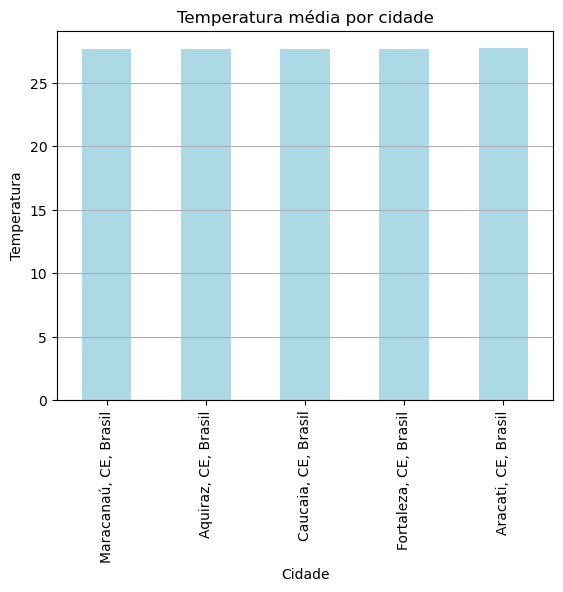

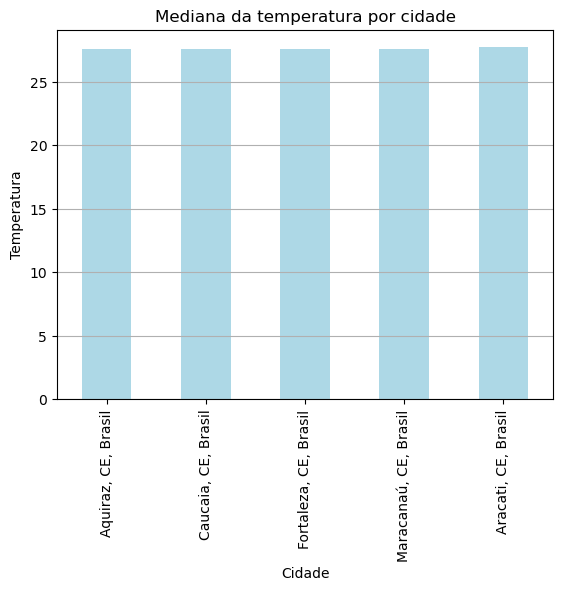

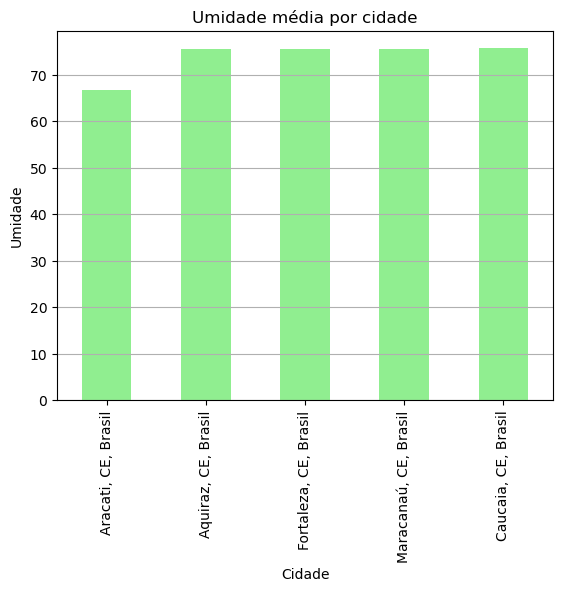

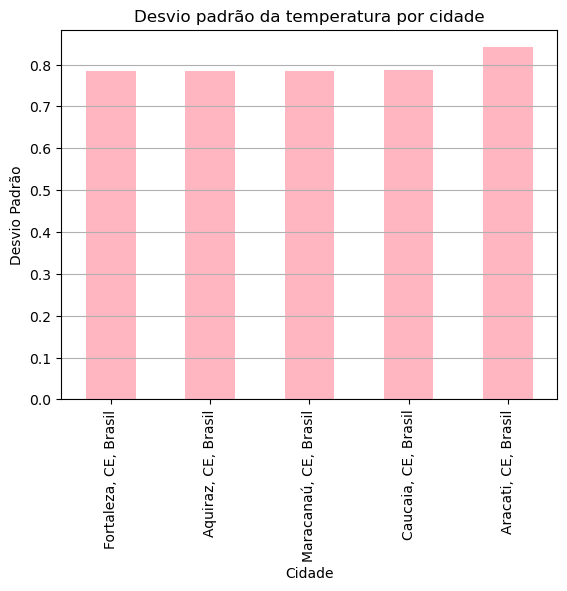

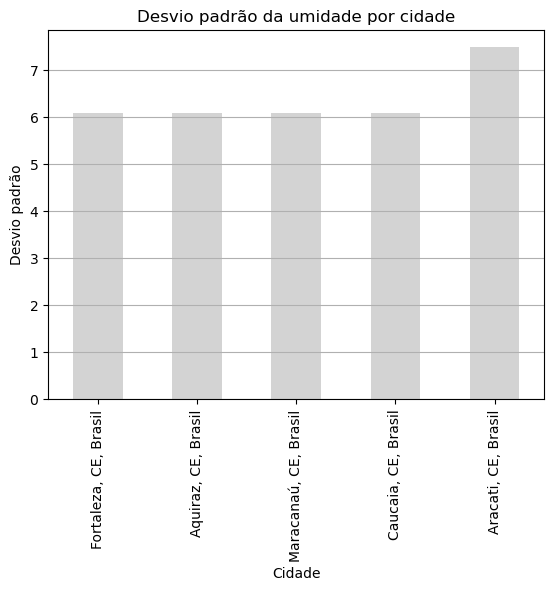

In [10]:
def plotar(metrica, titulo, y_label, cor):
    metrica.sort_values().plot(kind='bar', color=cor)
    plt.title(f'{titulo} por cidade')
    plt.ylabel(y_label)
    plt.xlabel('Cidade')
    plt.grid(axis='y')
    plt.show()

# tendências centrais
media_temp = dados.groupby('name')['temp'].mean()
mediana_temp = dados.groupby('name')['temp'].median()
media_umidade = dados.groupby('name')['humidity'].mean()

# medida de dispersão
std_temp = dados.groupby('name')['temp'].std()
std_umidade = dados.groupby('name')['humidity'].std()

plotar(media_temp, 'Temperatura média', 'Temperatura', 'lightblue')
plotar(mediana_temp, 'Mediana da temperatura', 'Temperatura', 'lightblue')
plotar(media_umidade, 'Umidade média', 'Umidade', 'lightgreen')
plotar(std_temp, 'Desvio padrão da temperatura', 'Desvio Padrão', 'lightpink')
plotar(std_umidade, 'Desvio padrão da umidade', 'Desvio padrão', 'lightgrey')


#### <font color = green> Boxplot

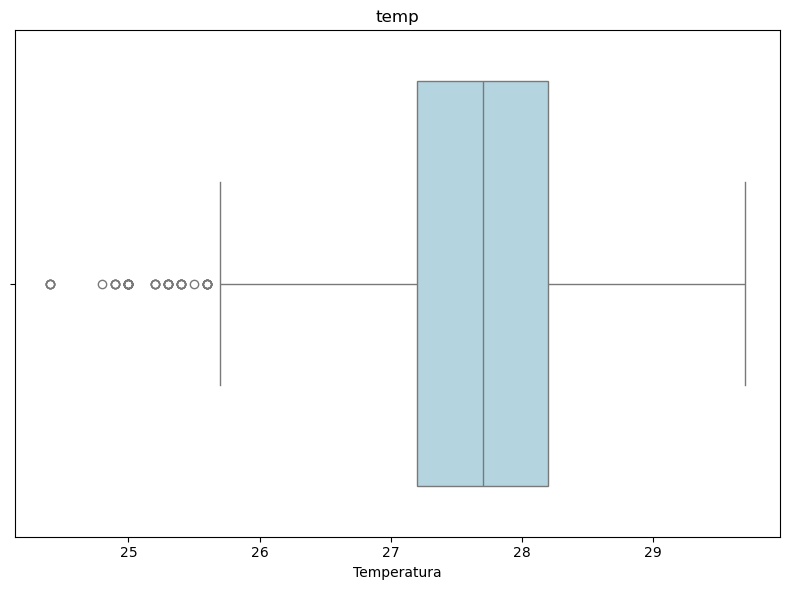

In [11]:
plt.figure(figsize=(8, 6))  

sns.boxplot(x=dados['temp'], orient='h', color='lightblue')

plt.title('temp')
plt.xlabel('Temperatura')
plt.tight_layout()

plt.show()

#### <font color = green> Histogramas

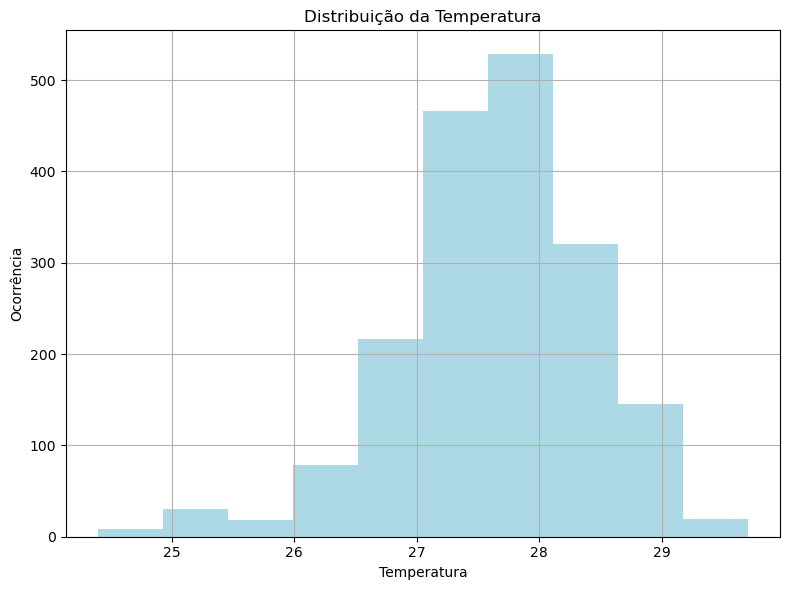

In [12]:
plt.figure(figsize=(8, 6))

dados['temp'].hist(color='lightblue')

plt.title('Distribuição da Temperatura')
plt.xlabel('Temperatura')
plt.ylabel('Ocorrência')
plt.tight_layout()

plt.show()

#### <font color = green> Classe Scatter

#### <font color = green> Scatter: Energia solar x Cidade x 'outro dado'

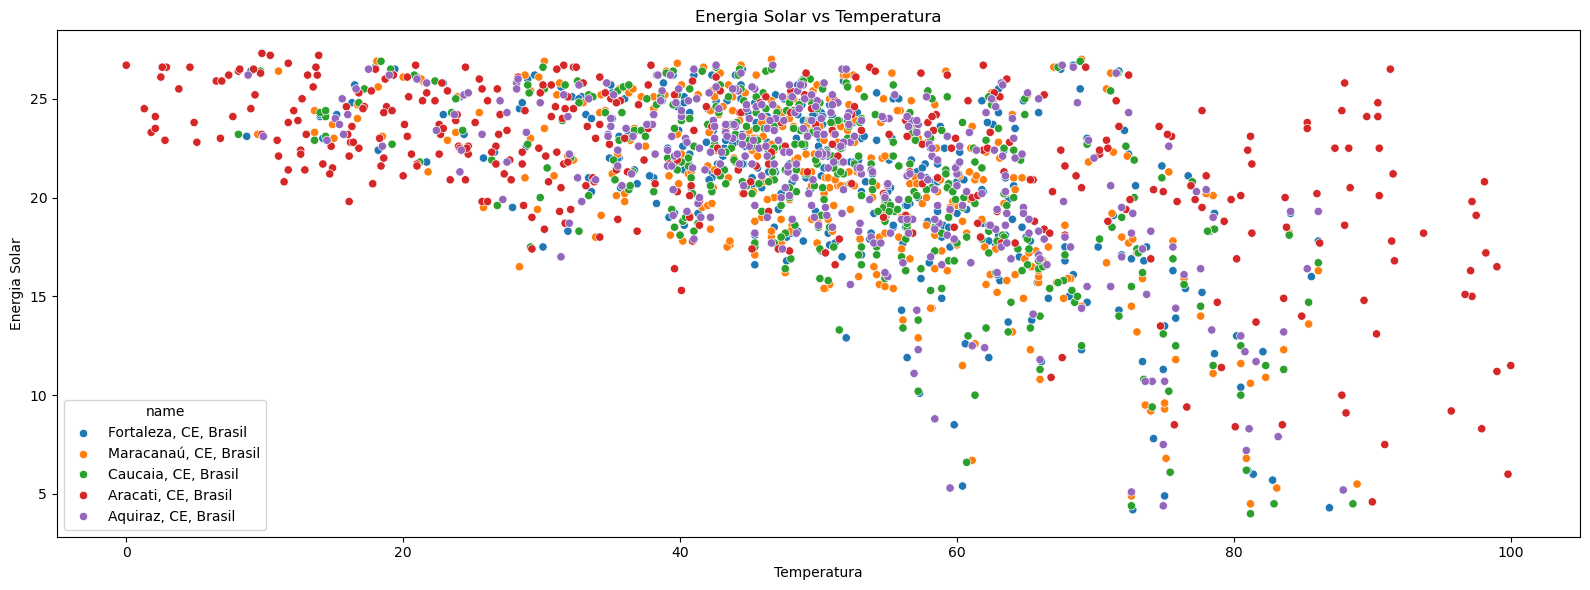

In [25]:
plt.figure(figsize=(16, 6))

sns.scatterplot(x=dados['cloudcover'], y=dados['solarenergy'], hue=dados['name'])

plt.title('Energia Solar vs Temperatura')
plt.xlabel('Temperatura')
plt.ylabel('Energia Solar')

#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### <font color = green> Matriz de correlação

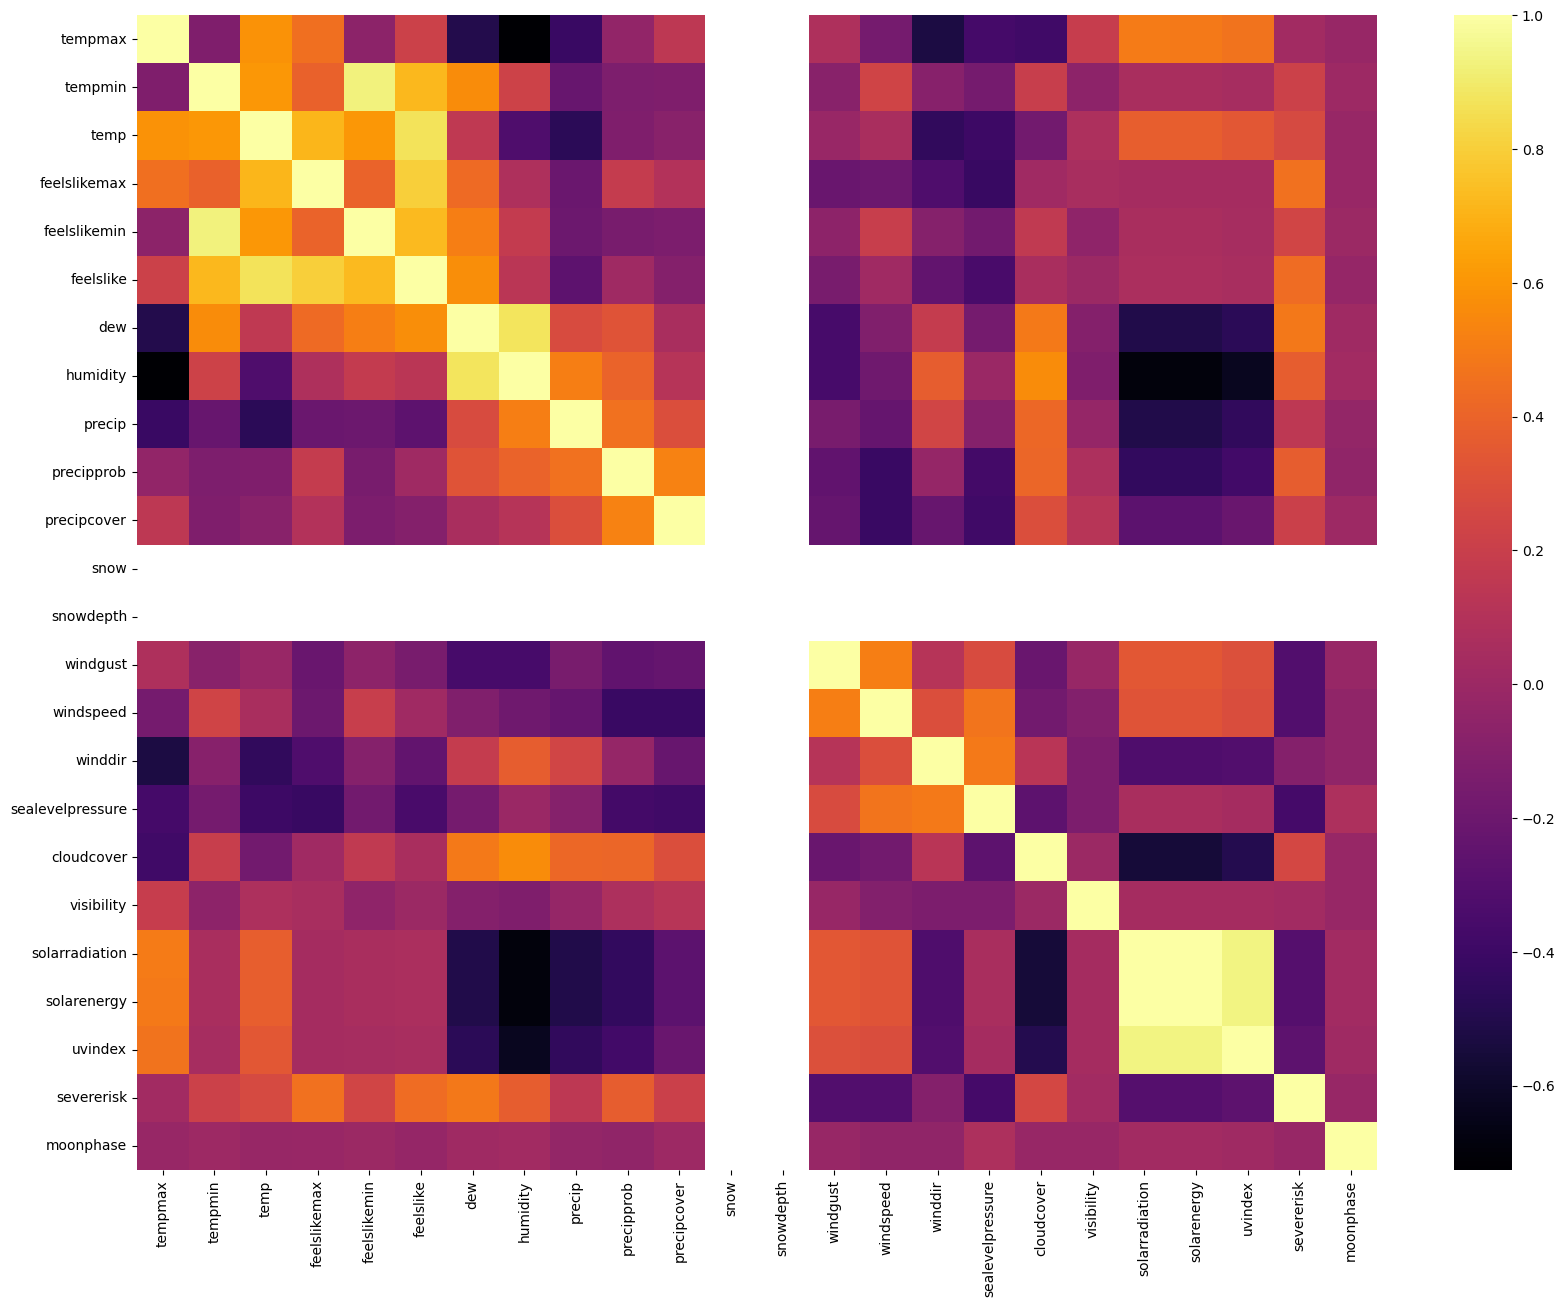

In [14]:
correlacao = dados.corr(numeric_only=True)

plt.figure(figsize=(20, 15))
ax = sns.heatmap(correlacao, cmap='inferno')
plt.show()


## <font color=purple> Preparando os dados

In [15]:
remover_colunas = ['snow', 'snowdepth', 'moonphase', 'uvindex', 'solarradiation', 'feelslikemax', 'feelslikemin', 'feelslike', 'windgust','severerisk', 'precip', 'precipprob','precipcover', 'preciptype']

dados_limpos = dados.drop(columns=remover_colunas).select_dtypes(include=[np.number]).dropna()

nan = dados_limpos.isna().sum()

#print(dados_limpos.shape)

In [16]:
# definindo o que vai ser atributo e label
atributos = dados_limpos.drop('solarenergy', axis=1)
label = dados_limpos['solarenergy']

label

0       19.5
1       19.1
2       19.3
3       21.9
4       20.6
        ... 
1825    23.1
1826    21.8
1827    14.4
1828    19.6
1829    20.6
Name: solarenergy, Length: 1830, dtype: float64

In [17]:
X_train, X_test, y_train, y_test = train_test_split(atributos, label, test_size=0.2, random_state=51)

## <font color=purple> Treinamentos

In [18]:
def treinar_modelo(modelo, X_train, y_train):
    modelo.fit(X_train, y_train)
    return modelo

def avaliar_modelo(modelo_treinado, X_test, y_test):
    y_pred = modelo_treinado.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f'MSE: {mse:.4f}')
    print(f'R²: {r2:.4f}')
    print(f'MAE: {mae:.4f}')
    
    return mse, r2, mae

def plotar_resultados(modelo_treinado, X_test, y_test, nome_modelo):
    y_pred = modelo_treinado.predict(X_test)
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, color='lightblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k', lw=2)
    plt.xlabel('Real')
    plt.ylabel('Predito')
    plt.title(f'{nome_modelo} - Real vs Predito')
    plt.show()


In [19]:
metricas = []

### <font color=blue> Linear regression

MSE: 6.6165
R²: 0.6228
MAE: 1.9518


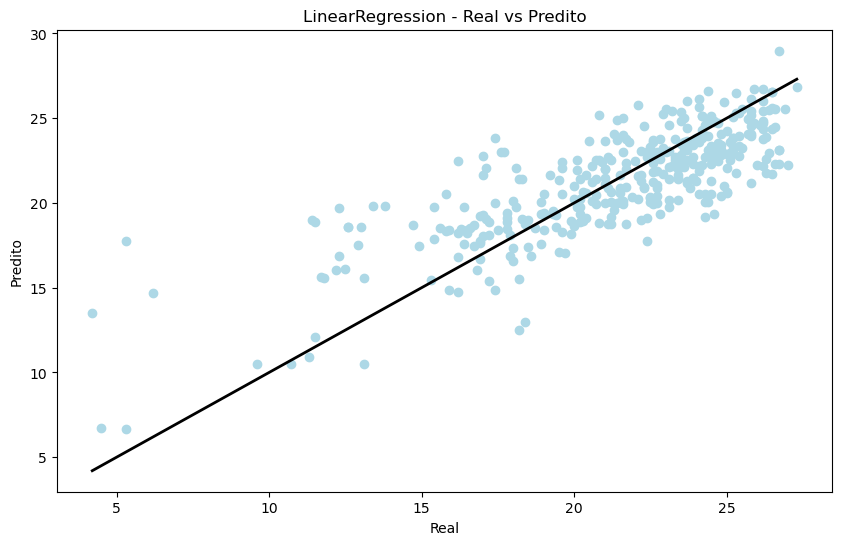

In [20]:
modelo = LinearRegression(fit_intercept=True)  

modelo_treinado = treinar_modelo(modelo, X_train, y_train)


metricas_linear_regression = avaliar_modelo(modelo_treinado, X_test, y_test)

plotar_resultados(modelo_treinado, X_test, y_test, "LinearRegression")

metricas.append(metricas_linear_regression)

### <font color=blue> Decision tree

MSE: 3.3160
R²: 0.8110
MAE: 1.1319


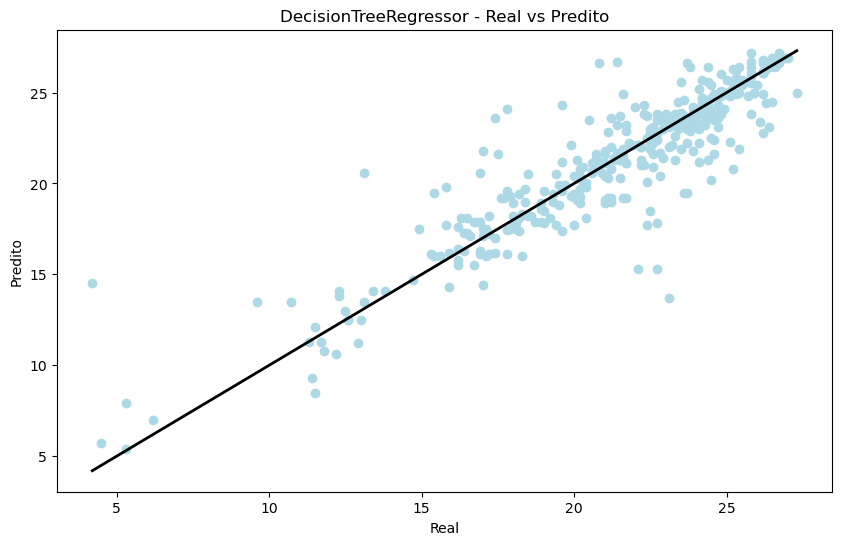

In [21]:

modelo = DecisionTreeRegressor()

modelo_treinado = treinar_modelo(modelo, X_train, y_train)

metricas_decision_tree = avaliar_modelo(modelo_treinado, X_test, y_test)

plotar_resultados(modelo_treinado, X_test, y_test, "DecisionTreeRegressor")

metricas.append(metricas_decision_tree)

### <font color=blue>  MLP

MSE: 7.4047
R²: 0.5778
MAE: 2.1822


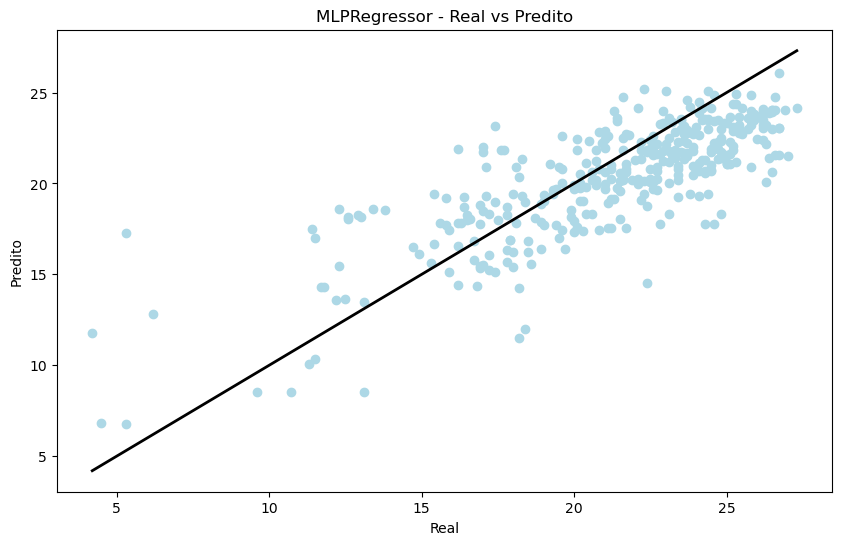

In [22]:

modelo = MLPRegressor(
    hidden_layer_sizes=(128, 64, 36),  
    max_iter=250,                      
    learning_rate_init=0.001,          
    random_state=51                   
)

modelo_treinado = treinar_modelo(modelo, X_train, y_train)

metricas_mlp = avaliar_modelo(modelo_treinado, X_test, y_test)

plotar_resultados(modelo_treinado, X_test, y_test, "MLPRegressor")

metricas.append(metricas_mlp)

## <font color = purple> Resultados

In [23]:
metricas_df = pd.DataFrame(metricas, columns=['MSE', 'R²', 'MAE'])
metricas_df

,MSE,R²,MAE
0,6.616527,0.622780,1.951765
1,3.315970,0.810951,1.131876
2,7.404731,0.577843,2.182221


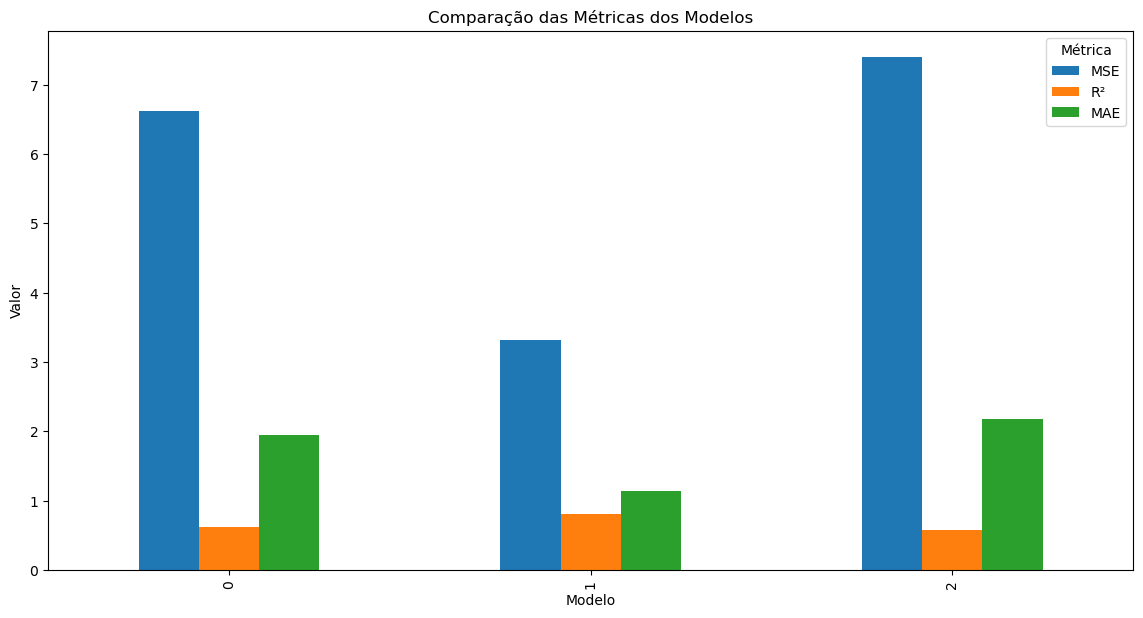

In [24]:
metricas_df.plot(kind='bar', figsize=(14, 7))
plt.xticks(ticks=range(len(metricas_df)))
plt.title('Comparação das Métricas dos Modelos')
plt.ylabel('Valor')
plt.xlabel('Modelo')
plt.legend(title='Métrica')
plt.show()
